In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [45]:
df = pd.read_csv('../Datasets/amazon_sales_dataset.csv')
df

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49996,2022-09-03,1433,Beauty,26.99,0,5,Middle East,Credit Card,2.4,386,26.99,134.95
49996,49997,2022-07-03,1428,Beauty,294.23,10,5,Asia,Credit Card,3.1,8,264.81,1324.05
49997,49998,2023-02-17,4651,Electronics,352.11,30,4,Asia,Debit Card,3.1,104,246.48,985.92
49998,49999,2022-09-30,4371,Beauty,307.54,5,1,Middle East,UPI,1.8,316,292.16,292.16


In [46]:
df.isnull().sum()

order_id            0
order_date          0
product_id          0
product_category    0
price               0
discount_percent    0
quantity_sold       0
customer_region     0
payment_method      0
rating              0
review_count        0
discounted_price    0
total_revenue       0
dtype: int64

In [47]:
df.product_category.unique()

array(['Books', 'Fashion', 'Sports', 'Beauty', 'Electronics',
       'Home & Kitchen'], dtype=object)

In [48]:
df.customer_region.unique()

array(['North America', 'Asia', 'Europe', 'Middle East'], dtype=object)

In [49]:
df.payment_method.unique()

array(['UPI', 'Credit Card', 'Wallet', 'Cash on Delivery', 'Debit Card'],
      dtype=object)

In [50]:
df = df.drop(['order_id','product_id'],axis=1)

In [51]:
df['Year'] = df.order_date.str[:4].astype('int')
df['Month'] = df.order_date.str[5:7].astype('int')

In [52]:
df.order_date = df.order_date.astype('datetime64[ns]')

In [53]:
df

,order_date,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue,Year,Month
0,2022-04-13,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52,2022,4
1,2023-03-12,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40,2023,3
2,2022-09-28,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28,2022,9
3,2022-04-17,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64,2022,4
4,2022-03-13,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72,2022,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,2022-09-03,Beauty,26.99,0,5,Middle East,Credit Card,2.4,386,26.99,134.95,2022,9
49996,2022-07-03,Beauty,294.23,10,5,Asia,Credit Card,3.1,8,264.81,1324.05,2022,7
49997,2023-02-17,Electronics,352.11,30,4,Asia,Debit Card,3.1,104,246.48,985.92,2023,2
49998,2022-09-30,Beauty,307.54,5,1,Middle East,UPI,1.8,316,292.16,292.16,2022,9


In [54]:
df.columns

Index(['order_date', 'product_category', 'price', 'discount_percent',
       'quantity_sold', 'customer_region', 'payment_method', 'rating',
       'review_count', 'discounted_price', 'total_revenue', 'Year', 'Month'],
      dtype='object')

In [55]:
df.dtypes

order_date          datetime64[ns]
product_category            object
price                      float64
discount_percent             int64
quantity_sold                int64
customer_region             object
payment_method              object
rating                     float64
review_count                 int64
discounted_price           float64
total_revenue              float64
Year                         int64
Month                        int64
dtype: object

In [56]:
df.total_revenue.sum()

np.float64(32866573.74)

In [57]:
df.quantity_sold.sum()

np.int64(149970)

In [58]:
df.discounted_price.mean()

np.float64(218.88656580000003)

In [59]:
df.total_revenue.mean()

np.float64(657.3314748)

In [60]:
category_revenue = df.groupby('product_category')['total_revenue'].sum().nlargest(6)
category_revenue

product_category
Beauty            5550624.97
Books             5484863.03
Fashion           5480123.34
Home & Kitchen    5473132.55
Electronics       5470594.03
Sports            5407235.82
Name: total_revenue, dtype: float64

In [61]:
category_quantity = df.groupby('product_category')['quantity_sold'].sum().nlargest(6)
category_quantity

product_category
Beauty            25422
Fashion           25089
Books             25065
Electronics       24898
Sports            24753
Home & Kitchen    24743
Name: quantity_sold, dtype: int64

In [62]:
region_revenue = df.groupby('customer_region')['total_revenue'].sum().nlargest()
region_revenue

customer_region
Middle East      8301844.50
North America    8277217.84
Asia             8175199.83
Europe           8112311.57
Name: total_revenue, dtype: float64

In [63]:
region_quantity = df.groupby('customer_region')['quantity_sold'].sum().nlargest()
region_quantity

customer_region
Middle East      37694
North America    37534
Asia             37440
Europe           37302
Name: quantity_sold, dtype: int64

In [64]:
paymethod_revenue = df.groupby('payment_method')['total_revenue'].sum().nlargest(10)
paymethod_revenue

payment_method
Wallet              6678638.47
UPI                 6579441.44
Cash on Delivery    6546386.94
Credit Card         6540087.16
Debit Card          6522019.73
Name: total_revenue, dtype: float64

In [65]:
df.payment_method.value_counts()

payment_method
Wallet              10106
UPI                 10078
Debit Card           9981
Cash on Delivery     9927
Credit Card          9908
Name: count, dtype: int64

In [66]:
monthly_sales = df.groupby(['Year','Month'])['total_revenue'].sum()
monthly_sales


Year  Month
2022  1        1419751.89
      2        1266714.29
      3        1392585.42
      4        1371955.83
      5        1374779.57
      6        1352125.49
      7        1346089.18
      8        1449308.06
      9        1403967.06
      10       1334818.11
      11       1291100.05
      12       1386209.61
2023  1        1464174.99
      2        1238380.51
      3        1366418.41
      4        1307017.94
      5        1431398.77
      6        1394822.13
      7        1442176.66
      8        1396321.88
      9        1341007.86
      10       1425936.23
      11       1334328.47
      12       1335185.33
Name: total_revenue, dtype: float64

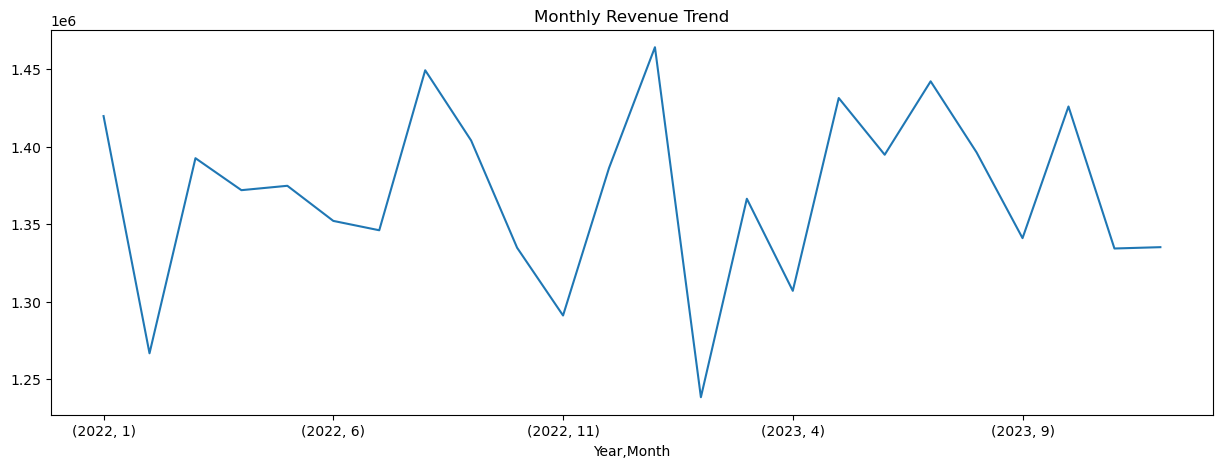

In [67]:
monthly_sales.plot(figsize=(15,5))
plt.title("Monthly Revenue Trend")
plt.show()


In [68]:
df[['discount_percent','quantity_sold']].corr()

,discount_percent,quantity_sold
discount_percent,1.000000,0.001399
quantity_sold,0.001399,1.000000


In [69]:
df[['discount_percent','total_revenue']].corr()

,discount_percent,total_revenue
discount_percent,1.000000,-0.144392
total_revenue,-0.144392,1.000000


In [70]:
df[['rating','total_revenue']].corr()

,rating,total_revenue
rating,1.000000,0.001804
total_revenue,0.001804,1.000000


In [71]:
df.groupby('product_category')['rating'].mean().nlargest(10)

product_category
Books             3.020259
Sports            2.996891
Home & Kitchen    2.996706
Electronics       2.991298
Fashion           2.987782
Beauty            2.985186
Name: rating, dtype: float64

In [72]:
df.groupby('product_category')['discount_percent'].mean().nlargest(6)

product_category
Sports            13.406534
Beauty            13.371530
Fashion           13.358637
Books             13.337336
Home & Kitchen    13.311334
Electronics       13.258413
Name: discount_percent, dtype: float64

In [73]:
df[['rating','total_revenue']].corr()

,rating,total_revenue
rating,1.000000,0.001804
total_revenue,0.001804,1.000000


In [74]:
df[['price','discounted_price','quantity_sold','total_revenue']].corr()

,price,discounted_price,quantity_sold,total_revenue
price,1.000000,0.974717,0.004405,0.711094
discounted_price,0.974717,1.000000,0.004457,0.729694
quantity_sold,0.004405,0.004457,1.000000,0.594404
total_revenue,0.711094,0.729694,0.594404,1.000000


In [75]:
(category_revenue / category_revenue.sum()) * 100

product_category
Beauty            16.888359
Books             16.688271
Fashion           16.673850
Home & Kitchen    16.652580
Electronics       16.644856
Sports            16.452082
Name: total_revenue, dtype: float64

In [76]:
df.sort_values(by='total_revenue', ascending=False).head(10)

,order_date,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue,Year,Month
27832,2022-03-04,Sports,499.91,0,5,North America,Wallet,1.8,230,499.91,2499.55,2022,3
10793,2023-03-13,Beauty,499.77,0,5,Europe,Debit Card,2.1,179,499.77,2498.85,2023,3
12127,2022-08-20,Home & Kitchen,498.76,0,5,Middle East,Wallet,3.2,365,498.76,2493.80,2022,8
23879,2022-09-16,Home & Kitchen,498.61,0,5,Europe,Credit Card,1.8,149,498.61,2493.05,2022,9
32943,2022-02-20,Books,498.50,0,5,Middle East,Wallet,3.2,5,498.50,2492.50,2022,2
30741,2022-01-14,Electronics,498.46,0,5,Europe,Debit Card,4.1,56,498.46,2492.30,2022,1
12834,2023-06-15,Home & Kitchen,497.70,0,5,Asia,Debit Card,3.9,383,497.70,2488.50,2023,6
18857,2022-06-20,Sports,497.46,0,5,North America,Debit Card,1.5,285,497.46,2487.30,2022,6
10449,2023-10-30,Electronics,497.17,0,5,Europe,UPI,4.6,71,497.17,2485.85,2023,10
33028,2023-07-26,Books,496.71,0,5,Asia,Cash on Delivery,3.4,443,496.71,2483.55,2023,7


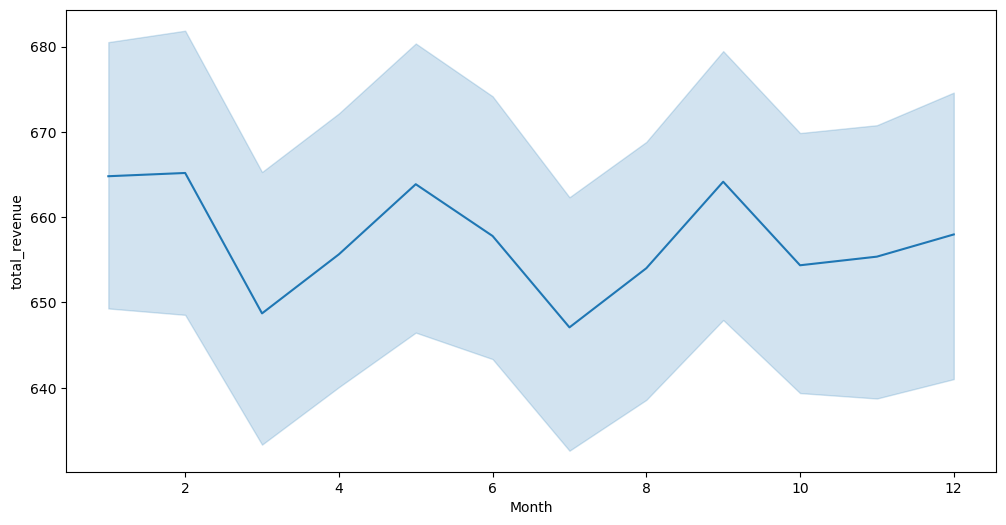

In [77]:
plt.figure(figsize=[12,6])
sb.lineplot(x =df.Month, y= df.total_revenue)
plt.show()

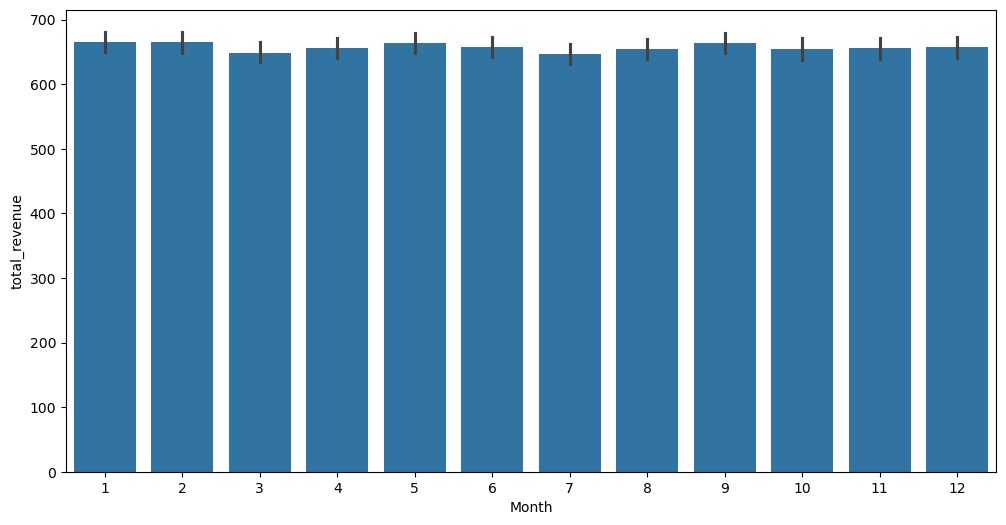

In [78]:
plt.figure(figsize=[12,6])
sb.barplot(x =df.Month, y= df.total_revenue)
plt.show()

In [79]:
df_year2023 = df[df.Year==2023]
df_year2022 = df[df.Year==2022]

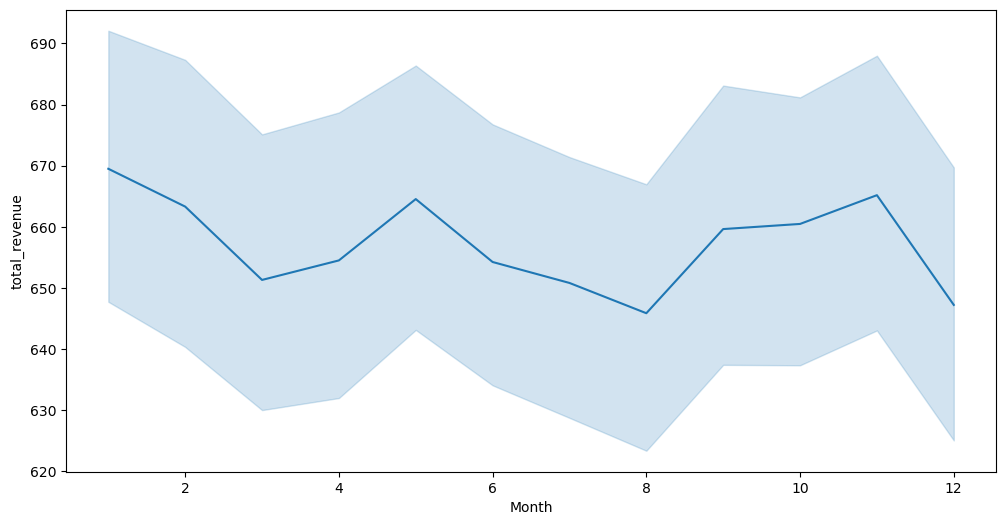

In [80]:
plt.figure(figsize=[12,6])
sb.lineplot(x=df_year2023.Month, y=df_year2023.total_revenue)
plt.show()